In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon

from docx import Document
from docx.shared import Inches, RGBColor

In [2]:
df = pd.read_csv('../../data/processed/dataset_14-23.csv')
trad = pd.read_csv('new_trained_results/trad_1423.csv')
prob = pd.read_csv('new_trained_results/prob_1423.csv')
rnn = pd.read_csv('new_trained_results/rnn_1423_weights.csv')

# Seasonal

12-2, 3-5, 6-8, 9-11

dec-feb, mar-may, jun-aug, sep-nov

In [3]:
# seasonal indexes

feb_idxs = trad[trad['datetime'].str.contains('02-28 23:00:00')].index.to_list()
# leap years
feb_idxs.remove(13793)
feb_idxs.remove(48651)
feb_29 = trad[trad['datetime'].str.contains('02-29 23:00:00')].index.to_list()
feb_idxs.extend(feb_29)

may_idxs = trad[trad['datetime'].str.contains('05-31 23:00:00')].index.to_list()
aug_idxs = trad[trad['datetime'].str.contains('08-31 23:00:00')].index.to_list()
nov_idxs = trad[trad['datetime'].str.contains('11-30 23:00:00')].index.to_list()

# combine all indexes
seasonal_idxs = feb_idxs + may_idxs + aug_idxs + nov_idxs
seasonal_idxs = [x+1 for x in seasonal_idxs] # adjust for 0 indexing
seasonal_idxs.extend([0, 82300])
seasonal_idxs.sort()

In [4]:
def num_to_month(num):
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    return months[num - 1]

In [5]:
# seasonal
def plot_power_curve(df, start, end, title_label, doc, seasonal=True, alpha=0.2):
    plt.figure(figsize=(7, 5))
    plt.scatter(df['speed'][start:end], df['power'][start:end], label='Historical', alpha=alpha)
    plt.scatter(df['speed'][start:end], df['preds'][start:end], label='Predicted', alpha=alpha)
    plt.xlabel('Wind Speed (m/s)', fontsize=16)
    plt.ylabel('Power (MW)', fontsize=16)
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.xlim(-0.5, 25.5)
    plt.ylim(-4, 254)

    # get start and end for title
    start_month = num_to_month(int(df['datetime'][start].split('-')[1]))
    start_year = int(df['datetime'][start].split('-')[0])
    end_month = num_to_month(int(df['datetime'][end-1].split('-')[1]))
    end_year = int(df['datetime'][end-1].split('-')[0])

    if seasonal:
        plt.title(f'{title_label} Power Curve ({start_month} {start_year} - {end_month} {end_year})', fontsize=20)
    else:
        plt.title(f'{title_label} Power Curve ({end_month} {end_year})', fontsize=20)

    leg = plt.legend(fontsize=14, loc='lower right')
    for l in leg.legend_handles:
        l.set_alpha(0.75)
    plt.tight_layout()

    # save to word doc
    img_path = f'plots/power_curve/power_{start_month}_{start_year}.png'
    plt.savefig(img_path)
    plt.close()
    doc.add_picture(img_path, width=Inches(2))

def plot_time_series(df, start, end, title_label, doc, seasonal=True, figsize=(25, 5)):
    plt.figure(figsize=figsize)
    plt.plot(df['power'][start:end], label='Historical')
    plt.plot(df['preds'][start:end], label='Predicted')
    plt.xlabel('Time', fontsize=20)
    plt.ylabel('Power (MW)', fontsize=20)
    plt.tick_params(axis='both', which='major', labelsize=14)

    # get start and end for title
    start_month = num_to_month(int(df['datetime'][start].split('-')[1]))
    start_year = int(df['datetime'][start].split('-')[0])
    end_month = num_to_month(int(df['datetime'][end-1].split('-')[1]))
    end_year = int(df['datetime'][end-1].split('-')[0])

    if seasonal:
        plt.title(f'{title_label} Time Series ({start_month} {start_year} - {end_month} {end_year})', fontsize=25)
    else:
        plt.title(f'{title_label} Time Series ({end_month} {end_year})', fontsize=25)

    plt.legend(fontsize=16, loc='upper left')
    plt.tight_layout()

    # save to word doc
    img_path = f'plots/time_series/time_{start_month}_{start_year}.png'
    plt.savefig(img_path)
    plt.close()
    doc.add_picture(img_path, width=Inches(6.5))

In [6]:
# metrics
def rmse(df):
    return np.round(np.sqrt(np.mean((df['npower'] - df['npreds']) ** 2)), 3)

def cc(df):
    return np.round(float(np.corrcoef(df['npower'], df['npreds'])[0, 1]), 3)

def similarity(df, bins=50): # power curve similarity
    H_true, _, _ = np.histogram2d(df['speed'], df['power'], bins=bins)
    H_pred, _, _ = np.histogram2d(df['speed'], df['preds'], bins=bins)
    H_true_norm = H_true / H_true.sum()
    H_pred_norm = H_pred / H_pred.sum()
    js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())
    similarity = 1 - js_div
    return np.round(float(similarity), 3)

In [7]:
def set_bold(cell, text):
    cell.text = ""
    run = cell.paragraphs[0].add_run(text)
    run.bold = True

def set_green(cell, text):
    cell.text = ""
    run = cell.paragraphs[0].add_run(text)
    run.font.color.rgb = RGBColor(0, 180, 0)

In [8]:
def add_metrics_table(doc, df_trad, df_prob, df_rnn, start, end):
    df_trad = df_trad[start:end].reset_index(drop=True)
    df_prob = df_prob[start:end].reset_index(drop=True)
    df_rnn = df_rnn[start:end].reset_index(drop=True)

    table = doc.add_table(rows=4, cols=4)

    set_bold(table.cell(0, 0), 'Metrics')
    set_bold(table.cell(0, 1), 'Trad')
    set_bold(table.cell(0, 2), 'Prob')
    set_bold(table.cell(0, 3), 'RNN')

    set_bold(table.cell(1, 0), 'RMSE')
    set_bold(table.cell(2, 0), 'CC')
    set_bold(table.cell(3, 0), 'Similarity')

    rmses = [rmse(df_trad), rmse(df_prob), rmse(df_rnn)]
    ccs = [cc(df_trad), cc(df_prob), cc(df_rnn)]
    simis = [similarity(df_trad), similarity(df_prob), similarity(df_rnn)]

    best_rmse_idx = np.argmin(rmses)
    best_cc_idx = np.argmax(ccs)
    best_simi_idx = np.argmax(simis)

    for i in range(3):
        if i == best_rmse_idx:
            set_green(table.cell(1, i + 1), str(rmses[i]))
        else:
            table.cell(1, i + 1).text = str(rmses[i])
        
        if i == best_cc_idx:
            set_green(table.cell(2, i + 1), str(ccs[i]))
        else:
            table.cell(2, i + 1).text = str(ccs[i])
        
        if i == best_simi_idx:
            set_green(table.cell(3, i + 1), str(simis[i]))
        else:
            table.cell(3, i + 1).text = str(simis[i])

In [9]:
# initialize word doc
doc = Document()

for i in range(0, len(seasonal_idxs) - 1):
    plot_power_curve(trad, seasonal_idxs[i], seasonal_idxs[i+1], 'Trad', doc)
    plot_power_curve(prob, seasonal_idxs[i], seasonal_idxs[i+1], 'Prob', doc)
    plot_power_curve(rnn, seasonal_idxs[i], seasonal_idxs[i+1], 'RNN', doc)

    plot_time_series(trad, seasonal_idxs[i], seasonal_idxs[i+1], 'Trad', doc)
    plot_time_series(prob, seasonal_idxs[i], seasonal_idxs[i+1], 'Prob', doc)
    plot_time_series(rnn, seasonal_idxs[i], seasonal_idxs[i+1], 'RNN', doc)

    add_metrics_table(doc, trad, prob, rnn, seasonal_idxs[i], seasonal_idxs[i+1])

# save doc
doc.save('seasonal_plots.docx')

In [96]:
# initialize word doc
doc = Document()

for i in range(0, len(seasonal_idxs) - 1):
    plot_power_curve(trad, seasonal_idxs[i], seasonal_idxs[i+1], 'Trad', doc)
    plot_power_curve(prob, seasonal_idxs[i], seasonal_idxs[i+1], 'Prob', doc)
    plot_power_curve(rnn, seasonal_idxs[i], seasonal_idxs[i+1], 'RNN', doc)

    plot_time_series(trad, seasonal_idxs[i], seasonal_idxs[i+1], 'Trad', doc, figsize=(35, 5))
    plot_time_series(prob, seasonal_idxs[i], seasonal_idxs[i+1], 'Prob', doc, figsize=(35, 5))
    plot_time_series(rnn, seasonal_idxs[i], seasonal_idxs[i+1], 'RNN', doc, figsize=(35, 5))

    add_metrics_table(doc, trad, prob, rnn, seasonal_idxs[i], seasonal_idxs[i+1])

# save doc
doc.save('seasonal_plots2.docx')

In [7]:
# calculate all seasonal metrics

seasonal_rmses = pd.DataFrame(columns=['trad', 'prob', 'rnn'])
seasonal_ccs = pd.DataFrame(columns=['trad', 'prob', 'rnn'])
seasonal_simis = pd.DataFrame(columns=['trad', 'prob', 'rnn'])

for i in range(0, len(seasonal_idxs) - 1):
    start = seasonal_idxs[i]
    end = seasonal_idxs[i+1]

    df_trad = trad[start:end].reset_index(drop=True)
    df_prob = prob[start:end].reset_index(drop=True)
    df_rnn = rnn[start:end].reset_index(drop=True)

    seasonal_rmses.loc[i] = [rmse(df_trad), rmse(df_prob), rmse(df_rnn)]
    seasonal_ccs.loc[i] = [cc(df_trad), cc(df_prob), cc(df_rnn)]
    seasonal_simis.loc[i] = [similarity(df_trad), similarity(df_prob), similarity(df_rnn)]

In [8]:
def plot_metric(df, metric_name, seasonal=True, figsize=(8, 4)):
    plt.figure(figsize=figsize)
    plt.plot(df['trad'], label='Trad')
    plt.plot(df['prob'], label='Prob')
    plt.plot(df['rnn'], label='RNN')
    plt.ylabel(metric_name, fontsize=14)

    if seasonal:
        plt.xlabel('Season Number', fontsize=14)
        plt.title(f'Seasonal {metric_name} Comparison', fontsize=16)
    else:
        plt.xlabel('Month Number', fontsize=14)
        plt.title(f'Monthly {metric_name} Comparison', fontsize=16)

    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.grid(alpha=0.5)
    plt.show()

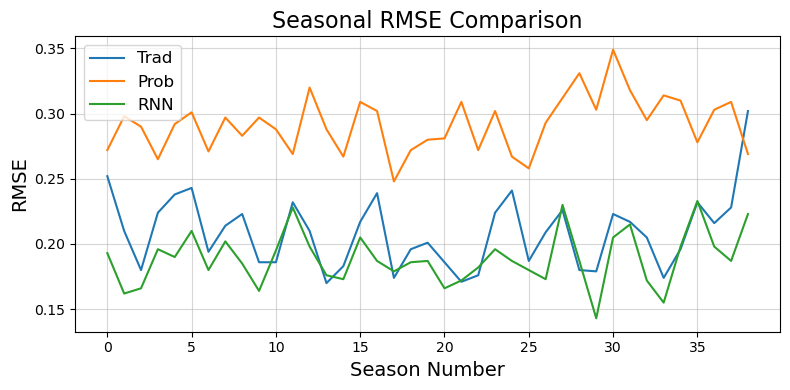

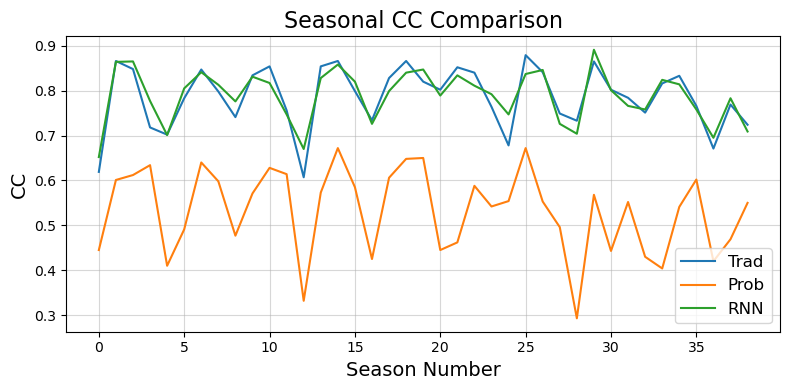

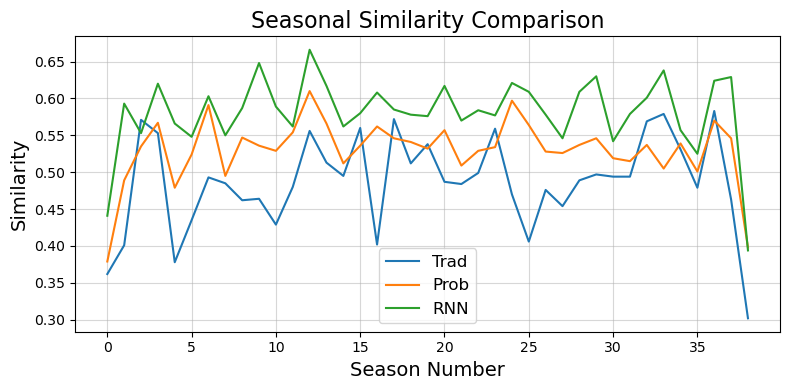

In [9]:
plot_metric(seasonal_rmses, 'RMSE')
plot_metric(seasonal_ccs, 'CC')
plot_metric(seasonal_simis, 'Similarity')

In [39]:
# plot individual seasons together

# indexes
jun_aug = np.arange(0, len(seasonal_rmses), 4)
sep_nov = np.arange(1, len(seasonal_rmses), 4)
dec_feb = np.arange(2, len(seasonal_rmses), 4)
mar_may = np.arange(3, len(seasonal_rmses), 4)

seasons = {
    'Jun-Aug': jun_aug,
    'Sep-Nov': sep_nov,
    'Dec-Feb': dec_feb,
    'Mar-May': mar_may
}



def plot_seasons(df, metric_name, figsize=(12, 6)):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=figsize)
    ax = ax.flatten()
    for i, season in enumerate(seasons):
        ax[i].plot(df['trad'][seasons[season]], label='Trad')
        ax[i].plot(df['prob'][seasons[season]], label='Prob')
        ax[i].plot(df['rnn'][seasons[season]], label='RNN')
        ax[i].set_ylabel(metric_name, fontsize=14)
        ax[i].set_xlabel('Season Number', fontsize=14)
        ax[i].set_title(f'{season} {metric_name} Comparison', fontsize=16)
        ax[i].legend(fontsize=12)
        ax[i].grid(alpha=0.5)
        ax[i].set_title(season)
        ax[i].legend(loc='upper left', fontsize=10)
    
    plt.suptitle(f'Seasonal {metric_name} Comparison', fontsize=18)
    plt.tight_layout()
    plt.show()


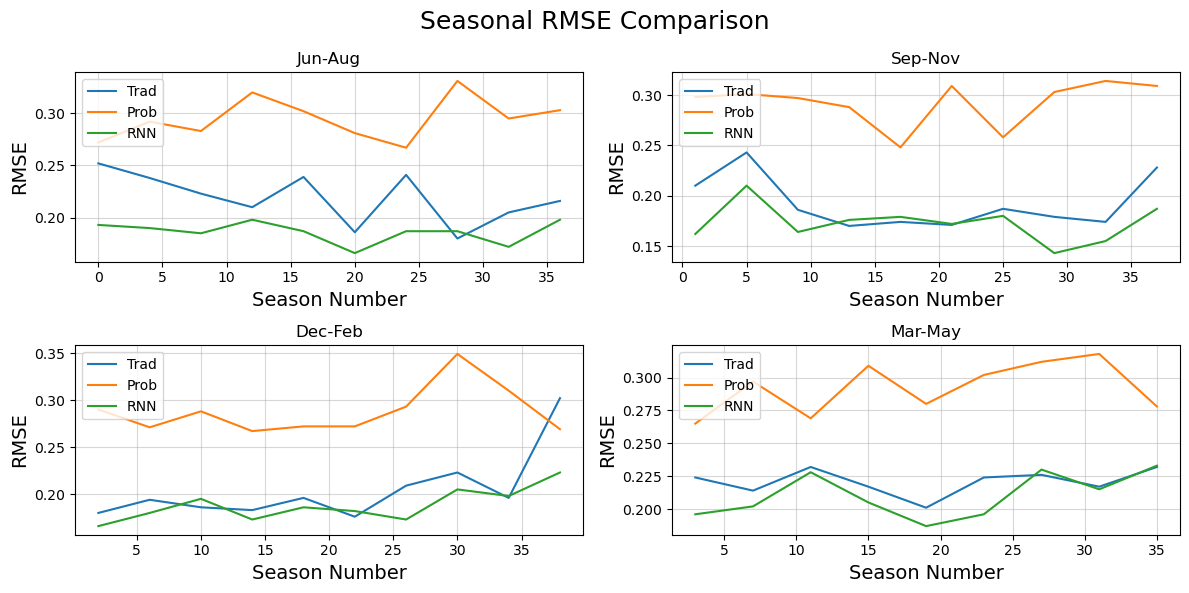

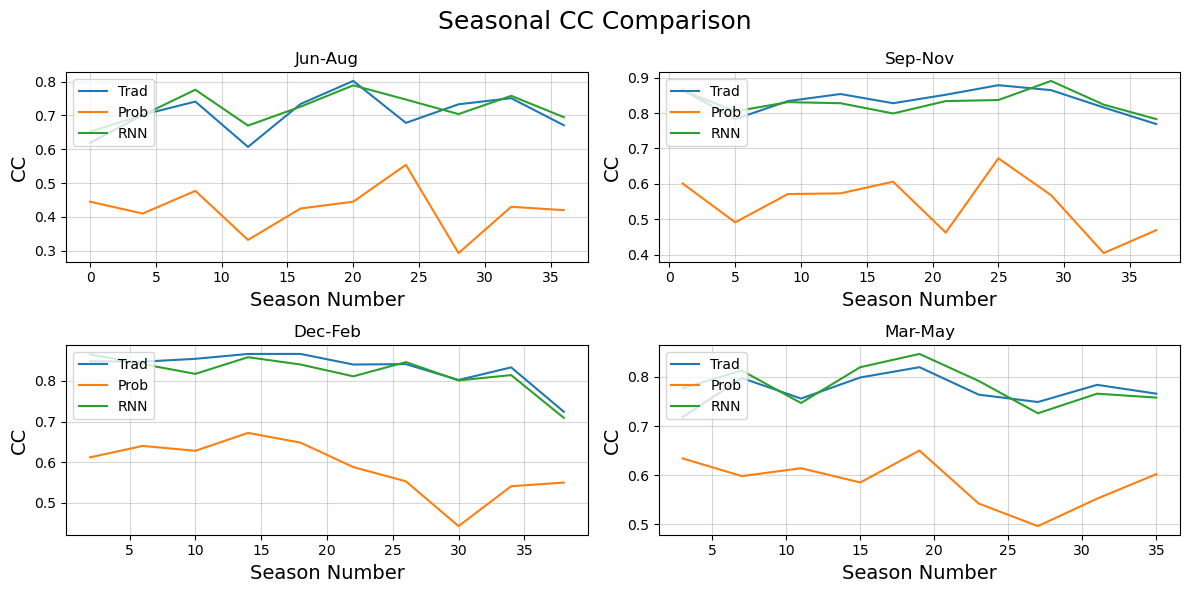

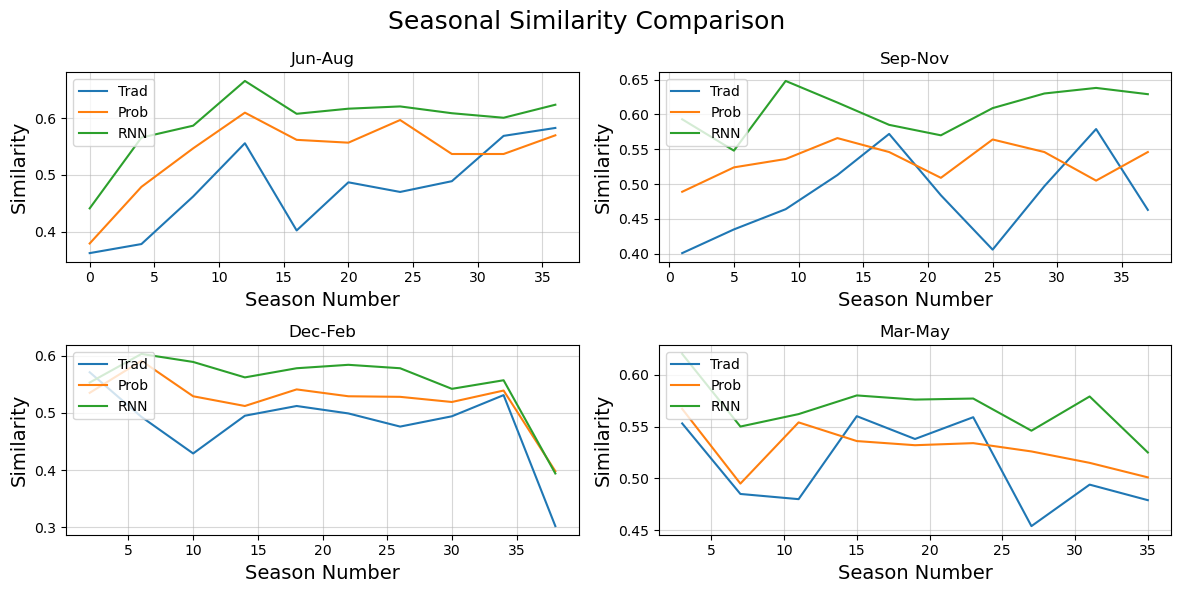

In [41]:
plot_seasons(seasonal_rmses, 'RMSE')
plot_seasons(seasonal_ccs, 'CC')
plot_seasons(seasonal_simis, 'Similarity')

In [42]:
print('Seasonal RMSEs')
print('Avg RMSE Trad:', np.round(seasonal_rmses['trad'].mean(), 3))
print('Avg RMSE Prob:', np.round(seasonal_rmses['prob'].mean(), 3))
print('Avg RMSE RNN:', np.round(seasonal_rmses['rnn'].mean(), 3))

print('\nSeasonal CCs')
print('Avg CC Trad:', np.round(seasonal_ccs['trad'].mean(), 3))
print('Avg CC Prob:', np.round(seasonal_ccs['prob'].mean(), 3))
print('Avg CC RNN:', np.round(seasonal_ccs['rnn'].mean(), 3))

print('\nSeasonal Similarities')
print('Avg Similarity Trad:', np.round(seasonal_simis['trad'].mean(), 3))
print('Avg Similarity Prob:', np.round(seasonal_simis['prob'].mean(), 3))
print('Avg Similarity RNN:', np.round(seasonal_simis['rnn'].mean(), 3))

Seasonal RMSEs
Avg RMSE Trad: 0.209
Avg RMSE Prob: 0.292
Avg RMSE RNN: 0.189

Seasonal CCs
Avg CC Trad: 0.786
Avg CC Prob: 0.533
Avg CC RNN: 0.789

Seasonal Similarities
Avg Similarity Trad: 0.487
Avg Similarity Prob: 0.53
Avg Similarity RNN: 0.581


In [43]:
color_map = {
    'trad': 'tab:blue',
    'prob': 'tab:orange',
    'rnn': 'tab:green'
}
labels = {
    'trad': 'Trad',
    'prob': 'Prob',
    'rnn': 'RNN'
}

def autopct_seasonal(pct):
    total = 39
    num = int(pct / 100. * total)
    return f"{pct:.1f}% ({num}/{total})"

def autopct_monthly(pct):
    total = 112
    num = int(pct / 100. * total)
    return f"{pct:.1f}% ({num}/{total})"

def plot_pie(df_metric, metric_name, rmse=False, seasonal=True):
    best = pd.DataFrame(columns=['trad', 'prob', 'rnn'])
    if rmse:
        best['trad'] = (df_metric['trad'] < df_metric['prob']) & (df_metric['trad'] < df_metric['rnn'])
        best['prob'] = (df_metric['prob'] < df_metric['trad']) & (df_metric['prob'] < df_metric['rnn'])
        best['rnn'] = (df_metric['rnn'] < df_metric['trad']) & (df_metric['rnn'] < df_metric['prob'])
    else:
        best['trad'] = (df_metric['trad'] > df_metric['prob']) & (df_metric['trad'] > df_metric['rnn'])
        best['prob'] = (df_metric['prob'] > df_metric['trad']) & (df_metric['prob'] > df_metric['rnn'])
        best['rnn'] = (df_metric['rnn'] > df_metric['trad']) & (df_metric['rnn'] > df_metric['prob'])
    counts = best.sum()
    counts = counts[counts > 0]
    plot_labels = [labels[key] for key in counts.index]
    plot_colors = [color_map[key] for key in counts.index]

    plt.figure(figsize=(5, 5))
    plt.pie(counts, labels=plot_labels, autopct=autopct_seasonal if seasonal else autopct_monthly, colors=plot_colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, textprops={'fontsize': 14})

    if seasonal:
        plt.title(f'Best Seasonal {metric_name}', fontsize=16)
    else:
        plt.title(f'Best Monthly {metric_name}', fontsize=16)
    
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

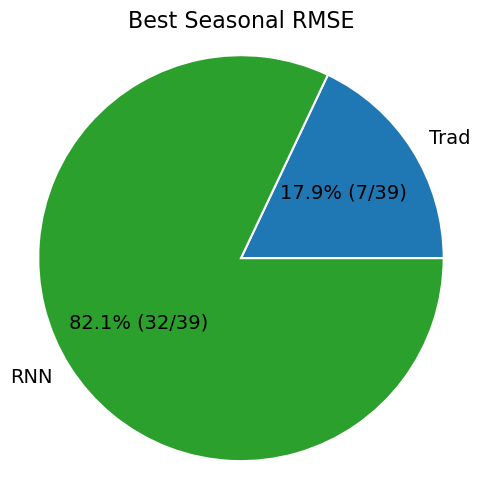

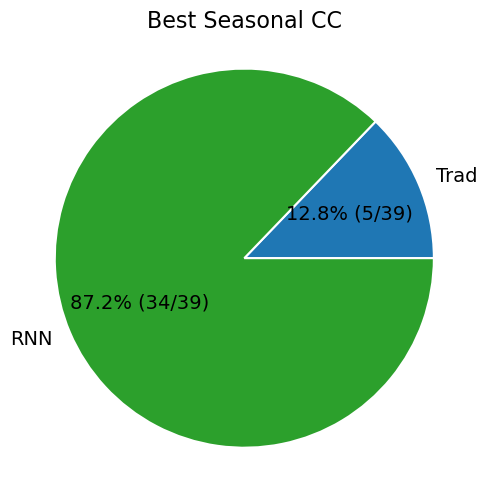

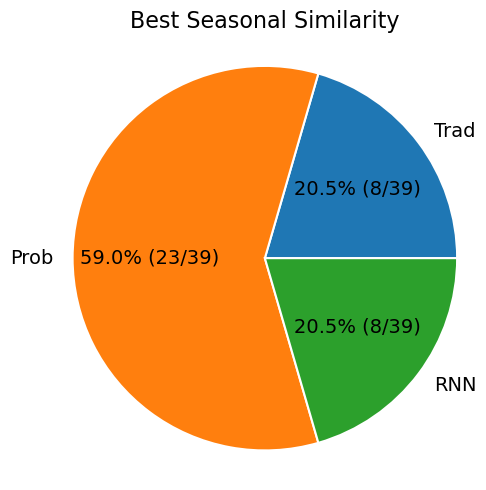

In [88]:
plot_pie(seasonal_rmses, 'RMSE', rmse=True)
plot_pie(seasonal_ccs, 'CC')
plot_pie(seasonal_simis, 'Similarity')

# Monthly

In [44]:
trad

,datetime,speed,power,npower,nspeed,power_lt,preds,npreds
0,2014-07-30 12:00:00,9.416307,222.814,0.912316,0.280607,127.309891,144.728839,0.591938
1,2014-07-30 13:00:00,8.168459,193.077,0.790557,0.243382,83.966250,100.373754,0.410527
2,2014-07-30 14:00:00,6.081183,166.707,0.682585,0.181116,33.846259,47.660244,0.194929
3,2014-07-30 15:00:00,3.644644,135.965,0.556711,0.108431,6.914308,15.657358,0.064038
4,2014-07-30 16:00:00,4.062179,103.724,0.424700,0.120886,9.680795,18.802193,0.076901
...,...,...,...,...,...,...,...,...
82295,2023-12-31 19:00:00,10.002887,14.636,0.059927,0.298106,149.547576,210.719675,0.861839
82296,2023-12-31 20:00:00,9.850973,5.243,0.021468,0.293574,143.779684,201.626479,0.824648
82297,2023-12-31 21:00:00,9.078698,0.446,0.001826,0.270536,114.821783,171.713819,0.702306
82298,2023-12-31 22:00:00,8.771991,0.195,0.000798,0.261387,103.897205,154.627952,0.632425


In [45]:
# seasonal indexes
jan_idxs = trad[trad['datetime'].str.contains('01-31 23:00:00')].index.to_list()

feb_idxs = trad[trad['datetime'].str.contains('02-28 23:00:00')].index.to_list()
feb_idxs.remove(13793) # leap year
feb_idxs.remove(48651) # leap year
feb_29 = trad[trad['datetime'].str.contains('02-29 23:00:00')].index.to_list()
feb_idxs.extend(feb_29)

mar_idxs = trad[trad['datetime'].str.contains('03-31 23:00:00')].index.to_list()
apr_idxs = trad[trad['datetime'].str.contains('04-30 23:00:00')].index.to_list()
may_idxs = trad[trad['datetime'].str.contains('05-31 23:00:00')].index.to_list()
jun_idxs = trad[trad['datetime'].str.contains('06-30 23:00:00')].index.to_list()
jul_idxs = trad[trad['datetime'].str.contains('07-31 23:00:00')].index.to_list()
aug_idxs = trad[trad['datetime'].str.contains('08-31 23:00:00')].index.to_list()
sep_idxs = trad[trad['datetime'].str.contains('09-30 23:00:00')].index.to_list()
oct_idxs = trad[trad['datetime'].str.contains('10-31 23:00:00')].index.to_list()
nov_idxs = trad[trad['datetime'].str.contains('11-30 23:00:00')].index.to_list()
dec_idxs = trad[trad['datetime'].str.contains('12-31 23:00:00')].index.to_list()

# combine all indexes
monthly_idxs = jan_idxs + feb_idxs + mar_idxs + apr_idxs + may_idxs + jun_idxs + jul_idxs + aug_idxs + sep_idxs + oct_idxs + nov_idxs + dec_idxs
monthly_idxs.remove(35) # first month not complete
monthly_idxs = [x+1 for x in monthly_idxs] # adjust for 0 indexing
monthly_idxs.extend([0]) # add 0
monthly_idxs.sort()

In [28]:
# save monthly plots and metrics into doc
doc = Document()

for i in range(0, len(monthly_idxs) - 1):
    plot_power_curve(trad, monthly_idxs[i], monthly_idxs[i+1], 'Trad', doc, seasonal=False)
    plot_power_curve(prob, monthly_idxs[i], monthly_idxs[i+1], 'Prob', doc, seasonal=False)
    plot_power_curve(rnn, monthly_idxs[i], monthly_idxs[i+1], 'RNN', doc, seasonal=False)

    plot_time_series(trad, monthly_idxs[i], monthly_idxs[i+1], 'Trad', doc, seasonal=False)
    plot_time_series(prob, monthly_idxs[i], monthly_idxs[i+1], 'Prob', doc, seasonal=False)
    plot_time_series(rnn, monthly_idxs[i], monthly_idxs[i+1], 'RNN', doc, seasonal=False)

    add_metrics_table(doc, trad, prob, rnn, monthly_idxs[i], monthly_idxs[i+1])

# save doc
doc.save('monthly_plots.docx')

In [46]:
# calculate all monthly metrics

monthly_rmses = pd.DataFrame(columns=['trad', 'prob', 'rnn'])
monthly_ccs = pd.DataFrame(columns=['trad', 'prob', 'rnn'])
monthly_simis = pd.DataFrame(columns=['trad', 'prob', 'rnn'])

for i in range(0, len(monthly_idxs) - 1):
    start = monthly_idxs[i]
    end = monthly_idxs[i+1]

    df_trad = trad[start:end].reset_index(drop=True)
    df_prob = prob[start:end].reset_index(drop=True)
    df_rnn = rnn[start:end].reset_index(drop=True)

    monthly_rmses.loc[i] = [rmse(df_trad), rmse(df_prob), rmse(df_rnn)]
    monthly_ccs.loc[i] = [cc(df_trad), cc(df_prob), cc(df_rnn)]
    monthly_simis.loc[i] = [similarity(df_trad), similarity(df_prob), similarity(df_rnn)]

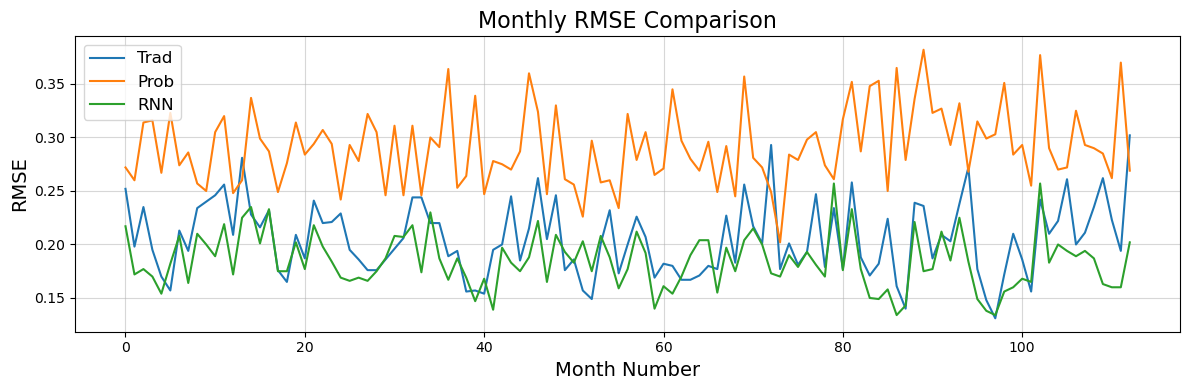

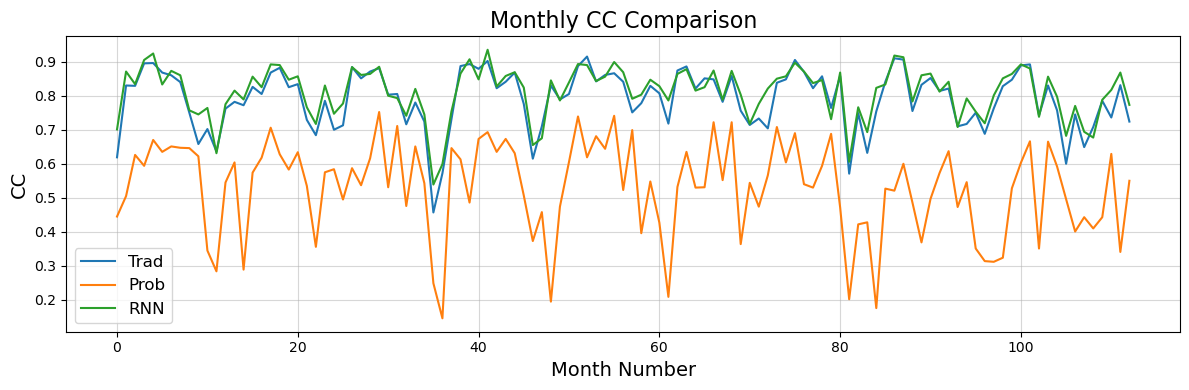

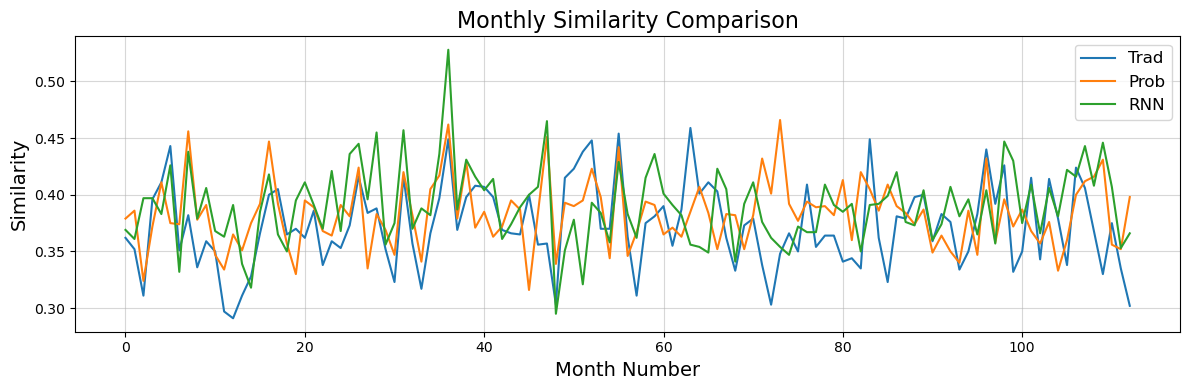

In [37]:
plot_metric(monthly_rmses, 'RMSE', seasonal=False, figsize=(12, 4))
plot_metric(monthly_ccs, 'CC', seasonal=False, figsize=(12, 4))
plot_metric(monthly_simis, 'Similarity', seasonal=False, figsize=(12, 4))

In [68]:
# monthly separated by year

# monthly december indexes
year_idxs = np.arange(4, len(monthly_idxs), 12)

def plot_monthly(df, metric_name, figsize=(12, 4)):
    plt.figure(figsize=figsize)
    plt.plot(df['trad'], label='Trad')
    plt.plot(df['prob'], label='Prob')
    plt.plot(df['rnn'], label='RNN')
    plt.ylabel(metric_name, fontsize=14)

    plt.xlabel('Month Number', fontsize=14)
    plt.title(f'Monthly {metric_name} Comparison Separated by Year', fontsize=16)

    plt.legend(fontsize=12)
    plt.vlines(x=year_idxs, ymin=0, ymax=df.max().max(), colors='gray', linestyles='dashed', label='Year Boundary')

    plt.tight_layout()
    plt.grid(axis='y', alpha=0.5)
    plt.show()

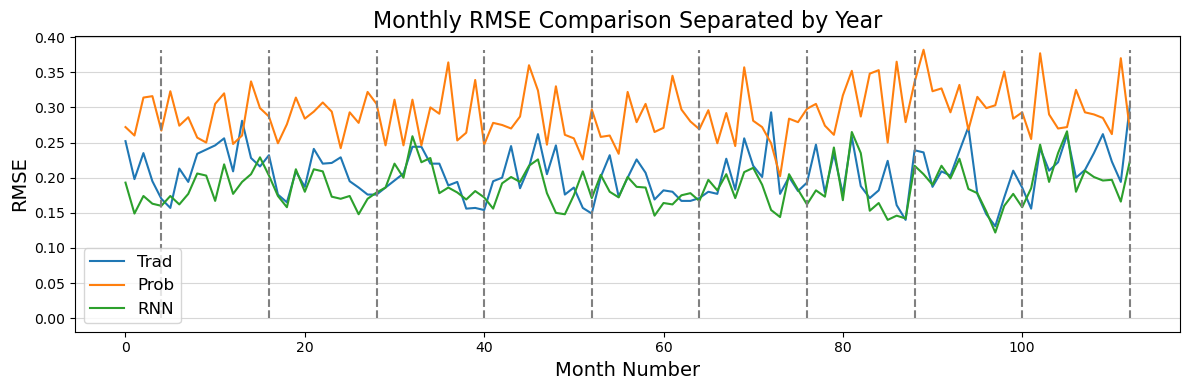

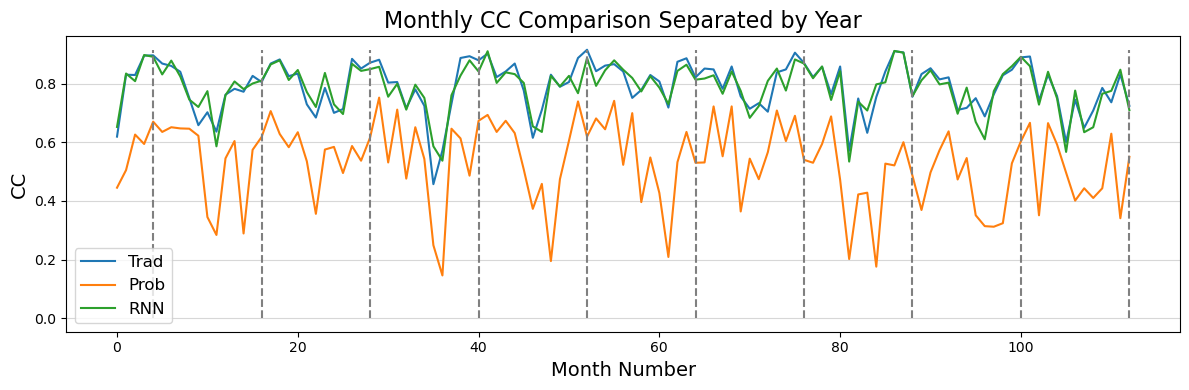

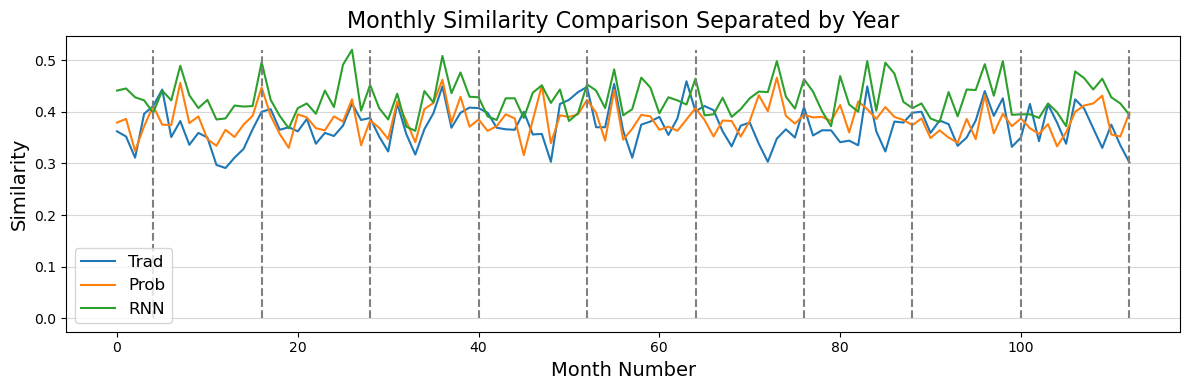

In [69]:
plot_monthly(monthly_rmses, 'RMSE')
plot_monthly(monthly_ccs, 'CC')
plot_monthly(monthly_simis, 'Similarity')

In [38]:
print('Monthly RMSEs')
print('Avg RMSE Trad:', np.round(monthly_rmses['trad'].mean(), 3))
print('Avg RMSE Prob:', np.round(monthly_rmses['prob'].mean(), 3))
print('Avg RMSE RNN:', np.round(monthly_rmses['rnn'].mean(), 3))

print('\nMonthly CCs')
print('Avg CC Trad:', np.round(monthly_ccs['trad'].mean(), 3))
print('Avg CC Prob:', np.round(monthly_ccs['prob'].mean(), 3))
print('Avg CC RNN:', np.round(monthly_ccs['rnn'].mean(), 3))

print('\nMonthly Similarities')
print('Avg Similarity Trad:', np.round(monthly_simis['trad'].mean(), 3))
print('Avg Similarity Prob:', np.round(monthly_simis['prob'].mean(), 3))
print('Avg Similarity RNN:', np.round(monthly_simis['rnn'].mean(), 3))

Monthly RMSEs
Avg RMSE Trad: 0.205
Avg RMSE Prob: 0.291
Avg RMSE RNN: 0.185

Monthly CCs
Avg CC Trad: 0.791
Avg CC Prob: 0.531
Avg CC RNN: 0.811

Monthly Similarities
Avg Similarity Trad: 0.372
Avg Similarity Prob: 0.383
Avg Similarity RNN: 0.39


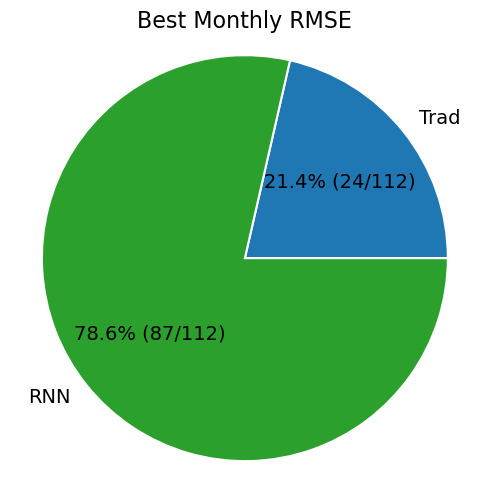

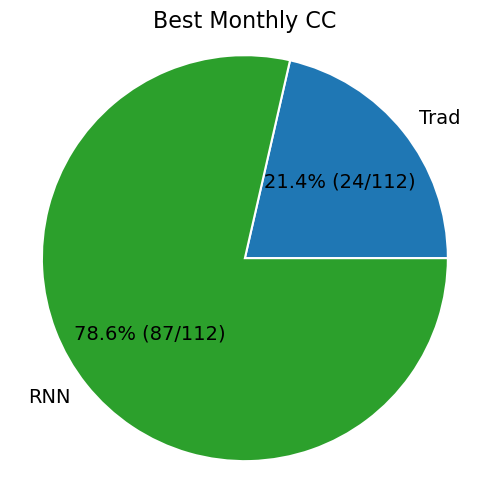

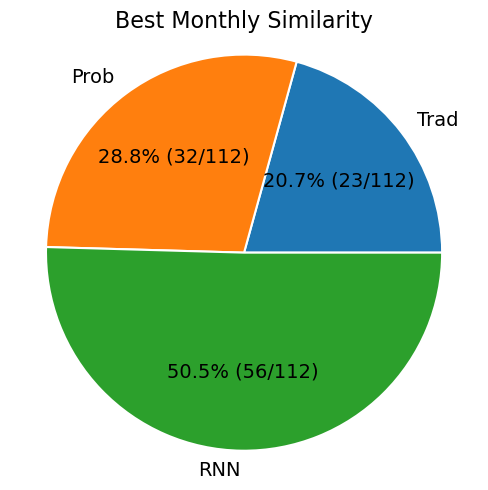

In [89]:
plot_pie(monthly_rmses, 'RMSE', rmse=True, seasonal=False)
plot_pie(monthly_ccs, 'CC', seasonal=False)
plot_pie(monthly_simis, 'Similarity', seasonal=False)